In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [7]:
df=pd.read_csv('height_weight.csv')

In [8]:
df.head()

,Height,Weight
0,190,72.4
1,165,53.2
2,164,47.9
3,184,62.6
4,155,40.0


Text(0, 0.5, 'Height')

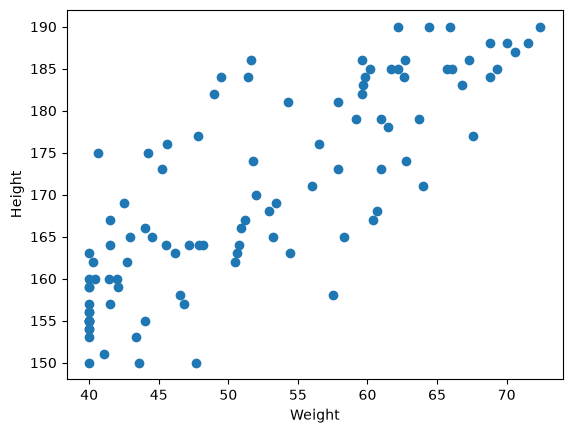

In [9]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [10]:
df.corr()

,Height,Weight
Height,1.000000,0.815737
Weight,0.815737,1.000000


In [11]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


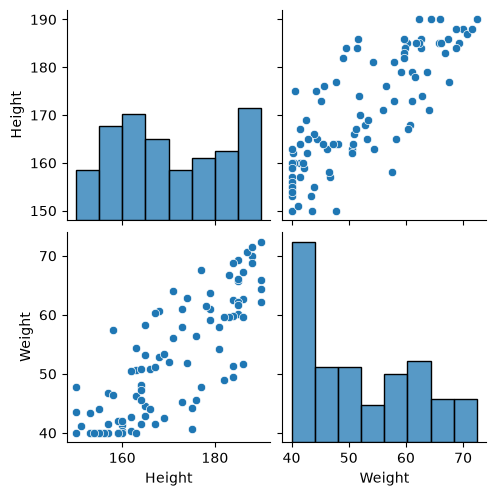

In [12]:
import seaborn as sns   
sns.pairplot(df)

In [13]:
##Divide into dependent and independent features
#Create independent features
X=df[['Height']]
X

,Height
0,190
1,165
2,164
3,184
4,155
...,...
95,181
96,163
97,186
98,186


In [14]:
np.array(X).shape

(100, 1)

In [15]:
#create dependent feature
y=df['Weight']
y

0     72.4
1     53.2
2     47.9
3     62.6
4     40.0
      ... 
95    57.9
96    40.0
97    59.6
98    51.6
99    56.5
Name: Weight, Length: 100, dtype: float64

In [16]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
##train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [19]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [22]:
X_test=scaler.transform(X_test)

c:\Users\KRITHI\OneDrive\Desktop\Machine_Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [23]:
#Simple linear regression
from sklearn.linear_model import LinearRegression
#initialise object
regression=LinearRegression(n_jobs=-1)
#fit regression model to training data
regression.fit(X_train,y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[8.12]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,52.66
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[8.66]


In [24]:
print("Slope or coefficient is:",regression.coef_)
print("Intercept is:",regression.intercept_)

Slope or coefficient is: [8.12332154]
Intercept is: 52.664


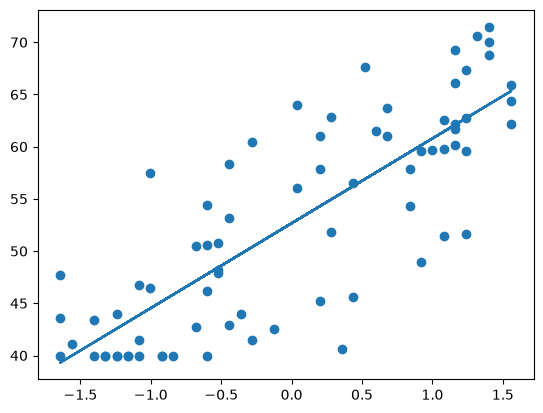

In [25]:
#plot training data best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

In [27]:
#Prediction of test data
regression.predict(X_test)

array([-58.65142982, -57.87078957, -57.55853348, -57.45444811,
       -58.80755787, -57.97487494, -58.33917372, -58.75551518,
       -58.54734445, -57.1942347 , -58.44325909, -58.75551518,
       -58.28713104, -58.49530177, -58.54734445, -59.0157286 ,
       -59.0157286 , -57.5064908 , -58.75551518, -58.3912164 ,
       -57.76670421, -58.54734445, -58.33917372, -58.23508835,
       -57.5064908 ])

In [ ]:
#performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

11899.062026919531
108.68647737870377
109.08282186907127


In [33]:
#Rsquare
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

-125.0016760912005


In [34]:
#adj r square
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

-130.48000983429617

In [36]:
%pip install statsmodels

  Obtaining dependency information for statsmodels from https://files.pythonhosted.org/packages/03/e3/d863228849da191d37c54bdd72634fbbcfadd12e910e29e4bdca1b952bb6/statsmodels-0.15.0-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for patsy>=0.5.6 from https://files.pythonhosted.org/packages/20/70/cd3cf5cff538323076a879edef02cce6f13f7d75e03d12f211b0a0dbd178/patsy-1.0.3-py2.py3-none-any.whl.metadata
  Obtaining dependency information for formulaic>=1.1.0 from https://files.pythonhosted.org/packages/fc/75/0576b03f7889ad25b5385b4f6c69e0543713425a6f193b056c9b0a2e65ce/formulaic-1.2.2-py3-none-any.whl.metadata
  Obtaining dependency information for interface-meta>=1.2.0 from https://files.pythonhosted.org/packages/a1/d3/20a61a248feb1249cd81f83ce731f0bdf5170ed96a08a298f7081cda9e90/interface_meta-2.0.1-py3-none-any.whl.metadata
  Obtaining dependency information for wrapt>=1.0 from https://files.pythonhosted.org/packages/d4/2a/47be56772bfb07ef242d6e924049688e38384af2b2fc99


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
#OLS technique
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()
prediction=model.predict(X_test)
print(prediction)
print(model.summary())



[-111.31542982 -110.53478957 -110.22253348 -110.11844811 -111.47155787
 -110.63887494 -111.00317372 -111.41951518 -111.21134445 -109.8582347
 -111.10725909 -111.41951518 -110.95113104 -111.15930177 -111.21134445
 -111.6797286  -111.6797286  -110.1704908  -111.41951518 -111.0552164
 -110.43070421 -111.21134445 -111.00317372 -110.89908835 -110.1704908 ]
                                 OLS Regression Results                                
Dep. Variable:                 Weight   R-squared (uncentered):                   0.023
Model:                            OLS   Adj. R-squared (uncentered):              0.010
Method:                 Least Squares   F-statistic:                              1.739
Date:                Mon, 21 Sep 2026   Prob (F-statistic):                       0.191
Time:                        11:18:52   Log-Likelihood:                         -404.17
No. Observations:                  75   AIC:                                      810.3
Df Residuals:                 

In [40]:
#prediction for new data
regression.predict(scaler.transform([[170]]))

c:\Users\KRITHI\OneDrive\Desktop\Machine_Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([52.32589624])